# (1) Optimization
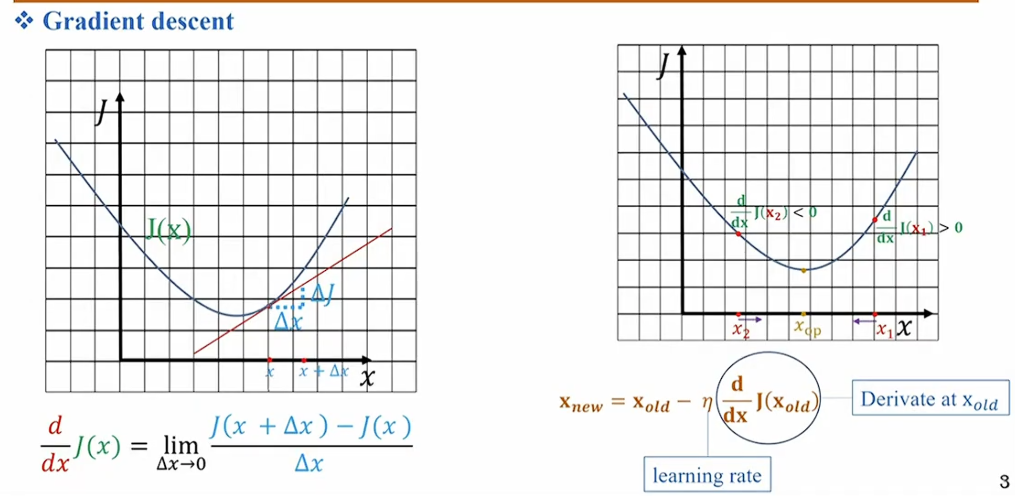
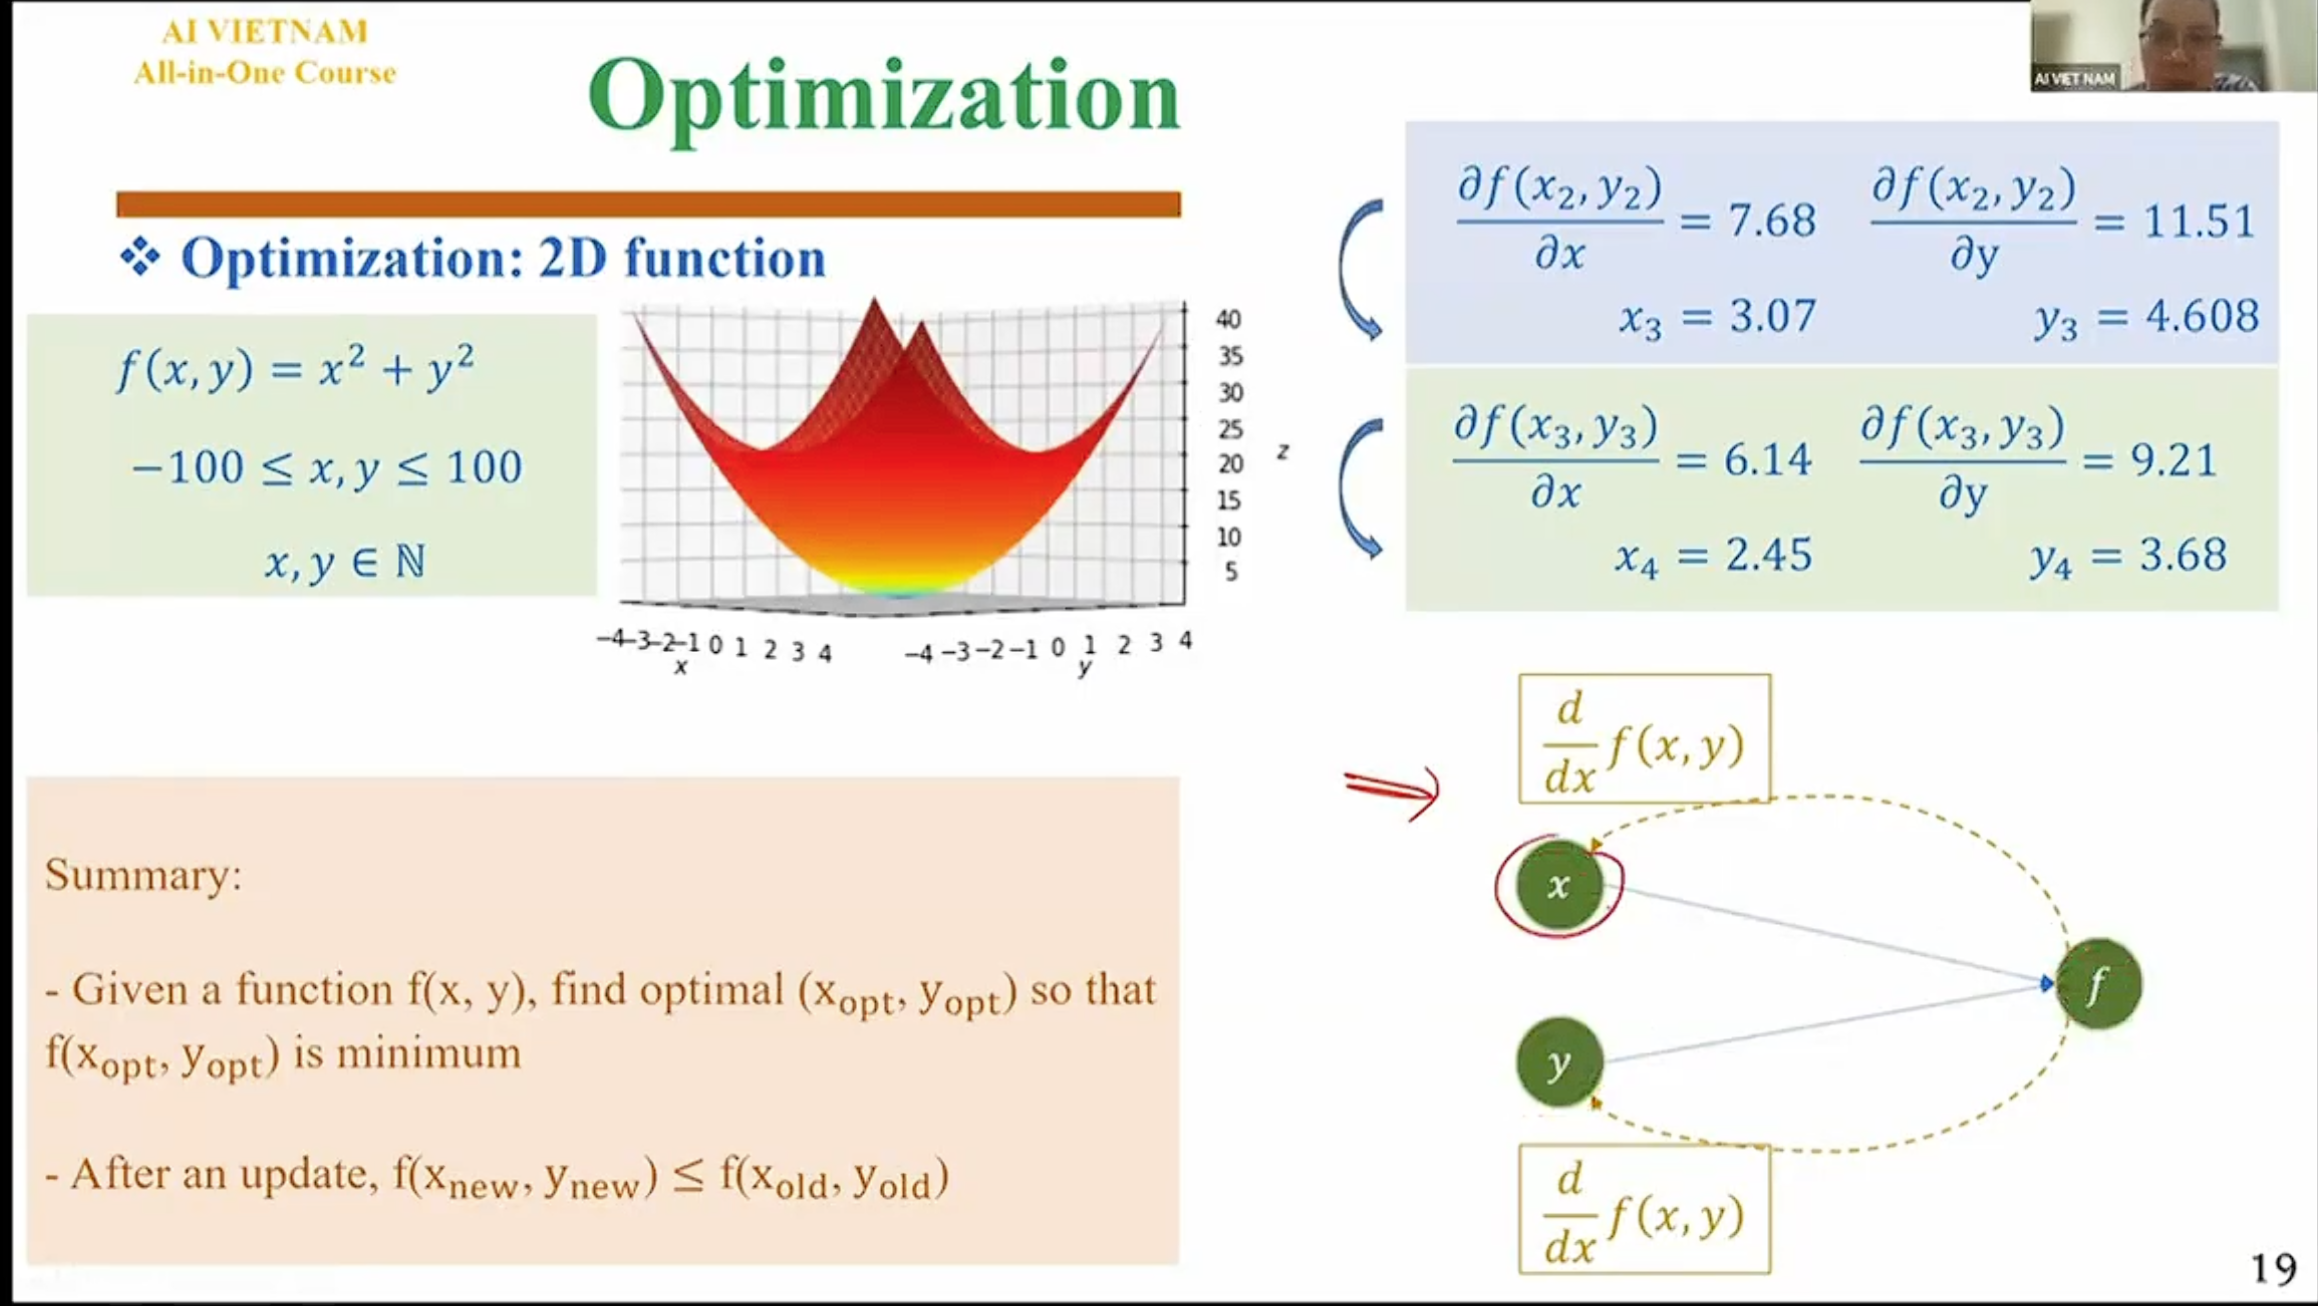

Epoch 0: w = 0.705, b = 0.132
Epoch 10: w = 1.256, b = 0.228
Epoch 20: w = 1.258, b = 0.222
Epoch 30: w = 1.259, b = 0.216
Epoch 40: w = 1.260, b = 0.210
Kết quả cuối cùng: w = 1.261, b = 0.205


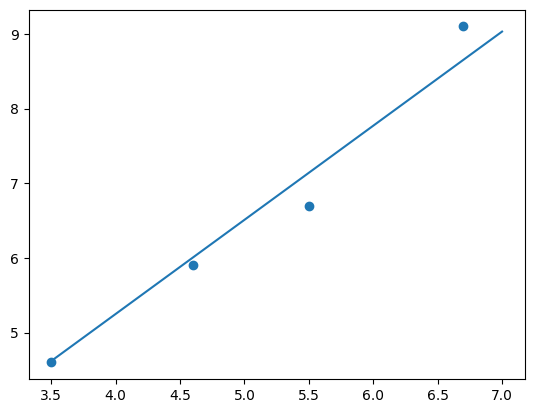

In [20]:
import matplotlib.pyplot as plt
import numpy as np
def predict(x, w, b):
    return w * x + b
def compute_gradient(x, y, w, b):
    n = len(x)
    y_pred = w * x + b
    error = y_pred - y

    dj_dw = (2 / n) * np.sum(error * x)
    dj_db = (2 / n) * np.sum(error)
    return dj_dw, dj_db

w_init = 0
b_init = 0
learning_rate = 0.01
epochs = 50
history = []

area = np.array([6.7, 4.6, 3.5, 5.5])
price = np.array([9.1, 5.9, 4.6, 6.7])

w = w_init
b = b_init

for i in range(epochs):
    dj_dw, dj_db = compute_gradient(area, price, w, b)

    w = w - learning_rate * dj_dw
    b = b - learning_rate * dj_db
    history.append((w, b, i))
    if i % 10 == 0:
        print(f"Epoch {i}: w = {w:.3f}, b = {b:.3f}")


print(f"Kết quả cuối cùng: w = {w:.3f}, b = {b:.3f}")

plt.scatter(area, price)
x_data = np.linspace(3.5, 7, 4)
final_result = [predict(x, w, b) for x in x_data]
plt.plot(x_data, final_result)


In [16]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# 1. Dữ liệu và Hàm tính Gradient (giữ nguyên)
area = np.array([6.7, 4.6, 3.5, 5.5])
price = np.array([9.1, 5.9, 4.6, 6.7])

def compute_gradient(x, y, w, b):
    n = len(x)
    y_pred = w * x + b
    error = y_pred - y
    dj_dw = (2 / n) * np.sum(error * x)
    dj_db = (2 / n) * np.sum(error)
    return dj_dw, dj_db

# 2. Tính toán trước lịch sử cập nhật (để animation mượt hơn)
w = 0.0
b = 0.0
alpha = 0.01
epochs = 50
history = []

for i in range(epochs):
    dj_dw, dj_db = compute_gradient(area, price, w, b)
    w = w - alpha * dj_dw
    b = b - alpha * dj_db
    history.append((w, b, i))

# 3. Thiết lập biểu đồ
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(area, price, color='blue', label='Data points')
line, = ax.plot([], [], color='red', label='Regression Line')
text = ax.text(0.05, 0.9, '', transform=ax.transAxes)

ax.set_xlim(min(area)-1, max(area)+1)
ax.set_ylim(min(price)-1, max(price)+1)
ax.set_xlabel('Area')
ax.set_ylabel('Price')
ax.set_title('Gradient Descent Animation')
ax.legend()

# 4. Hàm cập nhật frame
def update(frame):
    cur_w, cur_b, epoch = history[frame]
    
    # Vẽ đường thẳng
    x_vals = np.linspace(min(area)-1, max(area)+1, 100)
    y_vals = cur_w * x_vals + cur_b
    line.set_data(x_vals, y_vals)
    
    # Cập nhật thông số text
    text.set_text(f'Epoch: {epoch}\nw: {cur_w:.2f}\nb: {cur_b:.2f}')
    return line, text

# 5. Tạo Animation
ani = FuncAnimation(fig, update, frames=len(history), blit=True, interval=100)

# 6. HIỂN THỊ TRỰC TIẾP TRONG NOTEBOOK
# Lệnh này sẽ render ra một trình phát video bằng JS ngay bên dưới cell
plt.close() # Đóng plot tĩnh thừa để tránh bị in 2 lần
HTML(ani.to_jshtml())